##3 Task - 1:
Repeat all the task from worksheet - 5 but, try to improve the model from last week with same dataset.
• Use Data Augmentation to increase the number of training image.
• Use deeper model with BN and DropOut layer as presented above.
• Understand the Model Summary and Training Behavior.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

##Seting dataset path

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon.zip"
extract_path = "/content/Fruit"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done.")

Extraction done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(os.listdir(extract_path))
train_dir = "/content/Fruit/FruitinAmazon/train"

['FruitinAmazon']


In [ ]:
print(os.listdir(extract_path))
test_dir = "/content/Fruit/FruitinAmazon/test"

['FruitinAmazon']


##Visualizing one random image from each class

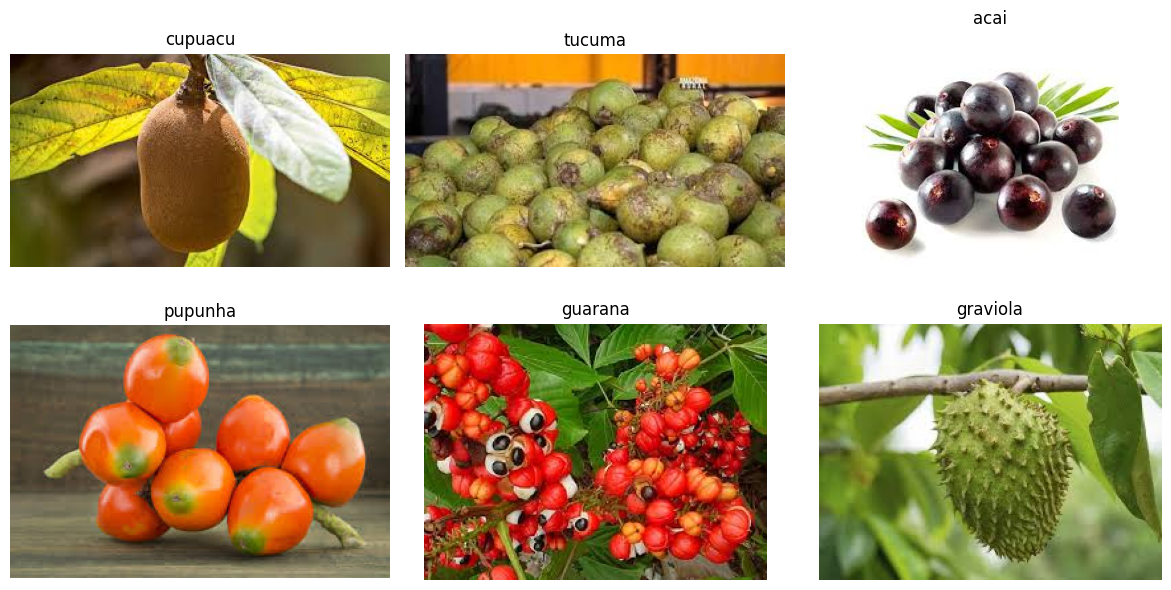

In [ ]:
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls
    )
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images)+1)//2, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

##Checking for any corrupted images

In [ ]:
corrupted = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


##Loading dataset

In [ ]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.3
seed = 123

##Training dataset

In [ ]:
# Load full dataset (no split here)
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

# Calculate sizes
total_batches = tf.data.experimental.cardinality(dataset).numpy()

train_size = int(0.7 * total_batches)
val_size = int(0.3 * total_batches)

# Split manually
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

Found 90 files belonging to 6 classes.


##Validation dataset

In [ ]:
from collections import Counter

train_labels = []
for _, y in train_ds:
    train_labels.extend(y.numpy())

print("Train:", Counter(train_labels))

val_labels = []
for _, y in val_ds:
    val_labels.extend(y.numpy())

print("Val:", Counter(val_labels))

Train: Counter({np.int32(1): 13, np.int32(0): 12, np.int32(2): 11, np.int32(3): 11, np.int32(5): 9, np.int32(4): 8})
Val: Counter({np.int32(1): 6, np.int32(4): 5, np.int32(5): 4, np.int32(2): 4, np.int32(0): 4, np.int32(3): 3})


##Testing dataset

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


##Normalize dataset

In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

if 'test_ds' in locals():
    test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

##Data augmentation

In [ ]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

##Build improved deeper CNN with BN and Dropout

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.2)
])

In [ ]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

##Model Summary

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,246 (14.14 MB)

 Trainable params: 3,706,246 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

##Compile model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Add callbacks

In [ ]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

##Train model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 593ms/step - accuracy: 0.1719 - loss: 2.1288 - val_accuracy: 0.1538 - val_loss: 1.8977 - learning_rate: 3.0000e-04
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step - accuracy: 0.1406 - loss: 2.0349 - val_accuracy: 0.0769 - val_loss: 1.7945 - learning_rate: 3.0000e-04
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2031 - loss: 1.8889 - val_accuracy: 0.1923 - val_loss: 1.7227 - learning_rate: 3.0000e-04
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 866ms/step - accuracy: 0.2500 - loss: 1.7393 - val_accuracy: 0.5000 - val_loss: 1.6745 - learning_rate: 3.0000e-04
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 534ms/step - accuracy: 0.3438 - loss: 1.6860 - val_accuracy: 0.6923 - val_loss: 1.5885 - learning_rate: 3.0000e-04
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 0.3281 - loss: 1.6741 - val_accuracy: 0.6923 - val_loss: 1.5738 - learning_rate: 3.0000e-04
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.3906 - loss: 1.

##Plot training behaviour

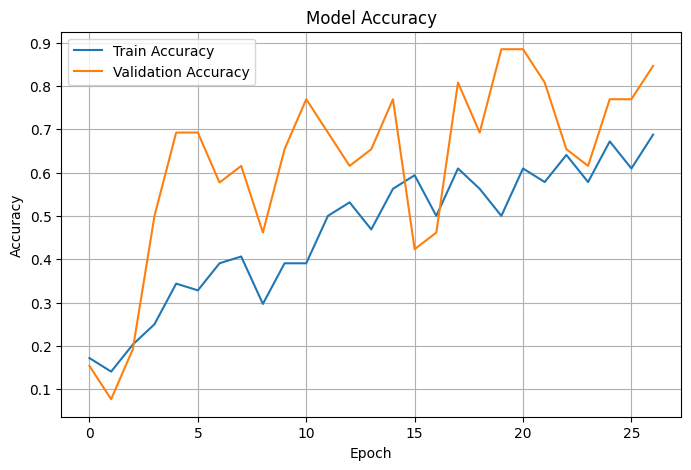

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)
plt.show()

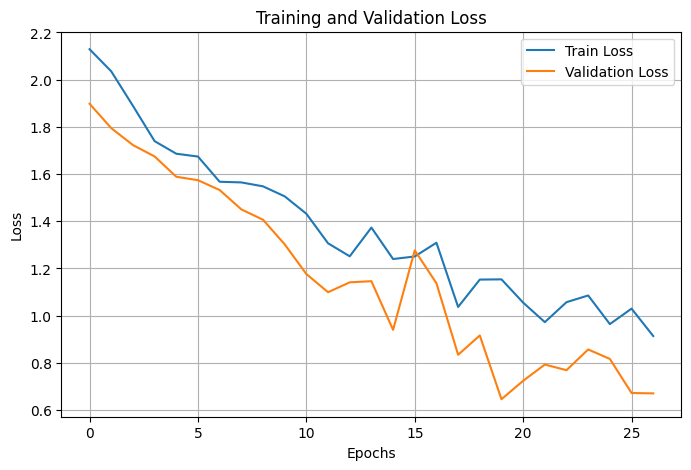

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

##Task2

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

##Loading dataset

##Train dataset

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 63 files for training.


##Validation dataset

In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 27 files for validation.


In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


##Get class names

In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


##Data augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

##Load pre-trained MobileNetV2 with ImageNet weights

In [ ]:
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##Freeze the base model

In [ ]:
base_model.trainable = False

##Build transfer learning model

In [ ]:
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

##model summary

In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##Compile model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Callbacks

In [ ]:
checkpoint = ModelCheckpoint(
    "transfer_learning_fruit_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

##Train the model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.0794 - loss: 2.3479 - val_accuracy: 0.4815 - val_loss: 1.3538
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 713ms/step - accuracy: 0.2540 - loss: 1.9220 - val_accuracy: 0.5185 - val_loss: 1.2940
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - accuracy: 0.6032 - loss: 1.1225 - val_accuracy: 0.7778 - val_loss: 1.0759
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.6032 - loss: 1.0031 - val_accuracy: 0.7778 - val_loss: 0.9681
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.7143 - loss: 0.8476 - val_accuracy: 0.7407 - val_loss: 0.8864
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 0.8254 - loss: 0.6854 - val_accuracy: 0.7407 - val_loss: 0.7910
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.7778 - loss: 0.5593 - val_accuracy: 0.8148 - val_loss: 0.7157
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 0.9048 - loss: 0.3855 - val_accuracy: 0.8148 - val_loss: 0.

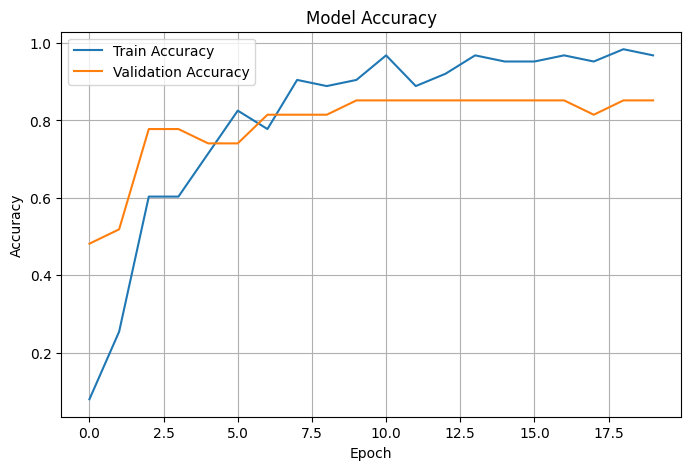

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)
plt.show()

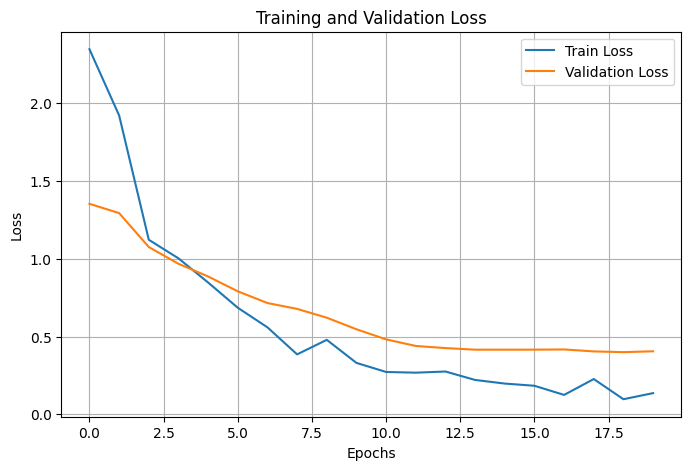

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()